<a href="https://colab.research.google.com/github/dhruvsuri8106-code/ECON-3916---Statistical-and-Machine-Learning/blob/main/Lab%2022%20/%20Lab_22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages (Colab-safe)
# -----------------------------------------------------------
!pip install wbgapi scikit-learn matplotlib seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import wbgapi as wb
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

np.random.seed(42)

print('Libraries loaded. Ready to cluster economies.')
# Note: An error related to an empty DataFrame was observed in a subsequent cell.
# The fix for that error should be applied in cell c3ZUNClgCPVn.

Libraries loaded. Ready to cluster economies.


In [31]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Download 10 development indicators for all countries
# -----------------------------------------------------------

indicators = {
    'NY.GDP.PCAP.PP.CD': 'gdp_per_capita_ppp',
    'SP.DYN.LE00.IN': 'life_expectancy',
    'SP.DYN.IMRT.IN': 'infant_mortality',
    'SE.PRM.ENRR': 'primary_enrollment',
    'SI.POV.GINI': 'gini_index',
    'EN.ATM.CO2E.PC': 'co2_per_capita',
    'IT.NET.USER.ZS': 'internet_users_pct',
    'NE.TRD.GNFS.ZS': 'trade_pct_gdp',
    'SL.UEM.TOTL.ZS': 'unemployment_rate',
    'SP.URB.TOTL.IN.ZS': 'urban_population_pct'
}

feature_names = list(indicators.values())

# Fetch data for the last 5 years to ensure more data points are collected.
# Use labels=True to get country names and numeric year columns.
df_raw = wb.data.DataFrame(list(indicators.keys()), mrv=5, labels=True)

# Reset index to make 'economy' and 'series' regular columns
df_raw_reset = df_raw.reset_index()

# Identify year columns (which are typically numeric strings 'YYYY')
id_vars = ['economy', 'series', 'Country']
year_cols = [col for col in df_raw_reset.columns if col not in id_vars]

# Melt the DataFrame to transform year columns into 'Time' and 'Value' columns
df_long = df_raw_reset.melt(id_vars=id_vars, value_vars=year_cols, var_name='Time', value_name='Value')

# Convert 'Value' column to numeric, coercing errors to NaN
df_long['Value'] = pd.to_numeric(df_long['Value'], errors='coerce')

# Map indicator codes to their descriptive names in the 'series' column
df_long['series'] = df_long['series'].map(indicators)

# Pivot to get indicators as columns, and 'economy', 'Country', 'Time' as index
df_pivot = df_long.pivot_table(index=['economy', 'Country', 'Time'], columns='series', values='Value')

# Reset index to make 'economy', 'Country' and 'Time' regular columns again
df_pivot = df_pivot.reset_index()

# Sort by economy and Time (descending) to easily pick the most recent data
df_pivot = df_pivot.sort_values(by=['economy', 'Time'], ascending=[True, False])

# Group by economy, then fill missing values backward (bfill) within each group.
# This ensures that for each indicator, the most recent non-null value from the 5-year window is chosen.
# Finally, take the first row of each group, which is the most recent processed data for that country.
# The 'economy' ID will become the index of the resulting df.
df = df_pivot.groupby('economy').apply(lambda x: x.bfill().iloc[0])

# The 'Time' column is no longer needed after extracting the most recent values.
df = df.drop(columns=['Time'])

# Drop countries with too much missing data (if any remaining after bfill and before imputation).
df = df.dropna(thresh=5)  # Keep countries with at least 5 of 10 indicators
df = df.fillna(df.median(numeric_only=True))  # Impute remaining NAs with column median

print(f'Countries retained: {len(df)}')
print(f'Features ({len(feature_names)}): {feature_names}')
print()

# Filter feature_names to only include columns present in df
initial_feature_names = feature_names.copy() # Keep a copy of the original list if needed later
feature_names = [f for f in feature_names if f in df.columns]

if len(feature_names) < len(initial_feature_names):
    missing_features = set(initial_feature_names) - set(feature_names)
    print(f"Warning: The following features were not found in the DataFrame and have been removed: {list(missing_features)}")
    print(f"Updated features ({len(feature_names)}): {feature_names}")
    print()

# Check if DataFrame is empty before trying to describe it
if not df.empty:
    print(df[feature_names].describe().round(1))
else:
    print("No countries retained after data cleaning. DataFrame is empty.")

Countries retained: 263
Features (10): ['gdp_per_capita_ppp', 'life_expectancy', 'infant_mortality', 'primary_enrollment', 'gini_index', 'co2_per_capita', 'internet_users_pct', 'trade_pct_gdp', 'unemployment_rate', 'urban_population_pct']

Updated features (9): ['gdp_per_capita_ppp', 'life_expectancy', 'infant_mortality', 'primary_enrollment', 'gini_index', 'internet_users_pct', 'trade_pct_gdp', 'unemployment_rate', 'urban_population_pct']

series  gdp_per_capita_ppp  life_expectancy  infant_mortality  \
count                263.0            263.0             263.0   
mean               29827.4             73.6              19.4   
std                28908.7              6.9              16.3   
min                 1194.9             54.6               1.2   
25%                 7989.7             68.6               6.9   
50%                20177.8             74.0              13.8   
75%                43860.7             78.5              29.6   
max               155941.3         

In [32]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 2: Standardize features with StandardScaler
# -----------------------------------------------------------

# Ensure feature_names only includes columns present in df
# This makes the scaling step robust to features removed during data cleaning.
feature_names = [f for f in feature_names if f in df.columns]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_names])

# Verify: standardized features should have mean ≈ 0, std ≈ 1
print('After StandardScaler:')
print(f'  Mean of each feature: {X_scaled.mean(axis=0).round(4)}')
print(f'  Std of each feature:  {X_scaled.std(axis=0).round(4)}')
print()
print(f'Shape of feature matrix: {X_scaled.shape}')
print(f'  {X_scaled.shape[0]} countries x {X_scaled.shape[1]} standardized features')

After StandardScaler:
  Mean of each feature: [ 0. -0.  0.  0. -0. -0. -0.  0.  0.]
  Std of each feature:  [1. 1. 1. 1. 1. 1. 1. 1. 1.]

Shape of feature matrix: (263, 9)
  263 countries x 9 standardized features


In [33]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 3: Fit K-Means and visualize with PCA
# -----------------------------------------------------------

# 3a. Fit K-Means with K=4
# Fill in: n_clusters, init method, and random_state
kmeans = KMeans(
    n_clusters=4,      # Number of clusters (match World Bank income groups)
    init='k-means++',            # Initialization method (string: 'k-means++')
    n_init='auto',
    random_state=42     # For reproducibility
)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Print cluster sizes
print('=== Cluster Sizes ===')
print(df['cluster'].value_counts().sort_index())
print()

# Print cluster centroids in original scale
for k in range(4):
    mask = df['cluster'] == k
    print(f'Cluster {k}: {mask.sum()} countries')
    print(f'  Avg GDP/capita (PPP): ${df.loc[mask, "gdp_per_capita_ppp"].mean():,.0f}')
    print(f'  Avg Life Expectancy:  {df.loc[mask, "life_expectancy"].mean():.1f} years')
    print(f'  Avg Infant Mortality: {df.loc[mask, "infant_mortality"].mean():.1f} per 1,000')
    print()

=== Cluster Sizes ===
cluster
0     67
1     32
2     16
3    148
Name: count, dtype: int64

Cluster 0: 67 countries
  Avg GDP/capita (PPP): $6,076
  Avg Life Expectancy:  65.6 years
  Avg Infant Mortality: 40.5 per 1,000

Cluster 1: 32 countries
  Avg GDP/capita (PPP): $84,014
  Avg Life Expectancy:  82.3 years
  Avg Infant Mortality: 5.0 per 1,000

Cluster 2: 16 countries
  Avg GDP/capita (PPP): $11,771
  Avg Life Expectancy:  66.8 years
  Avg Infant Mortality: 32.0 per 1,000

Cluster 3: 148 countries
  Avg GDP/capita (PPP): $30,815
  Avg Life Expectancy:  76.1 years
  Avg Infant Mortality: 11.5 per 1,000



Variance explained by PC1: 43.2%
Variance explained by PC2: 12.7%
Total variance explained:  55.9%


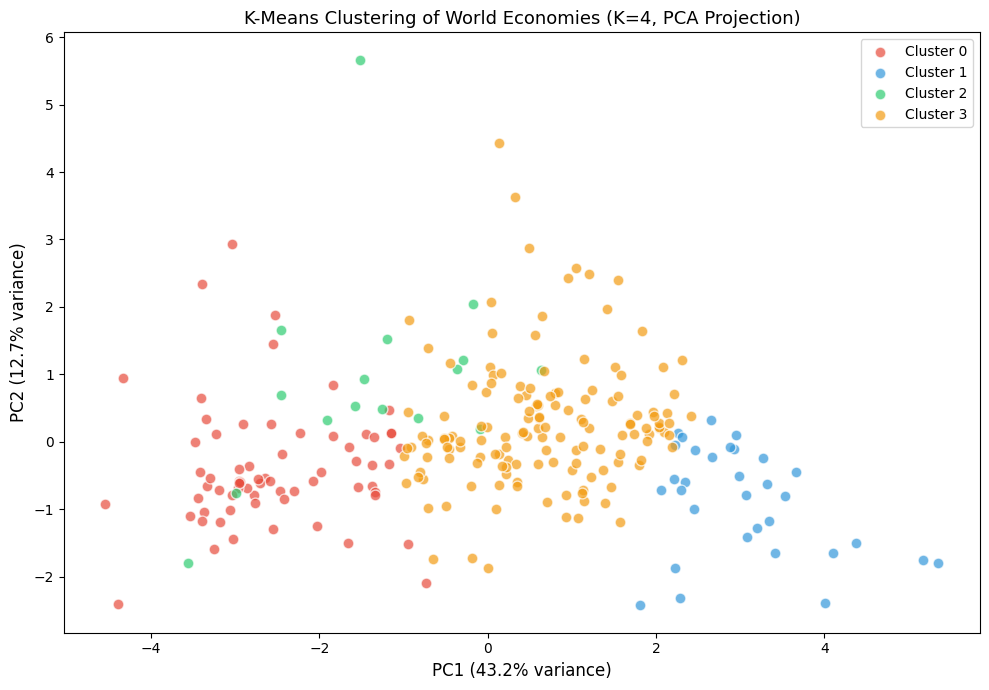

In [34]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 3b: PCA projection to 2D and scatter plot
# -----------------------------------------------------------

# Reduce 10 dimensions to 2 using PCA
# Fill in: how many components do we want for a 2D scatter plot?
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# How much variance do the first 2 PCs explain?
print(f'Variance explained by PC1: {pca.explained_variance_ratio_[0]:.1%}')
print(f'Variance explained by PC2: {pca.explained_variance_ratio_[1]:.1%}')
print(f'Total variance explained:  {sum(pca.explained_variance_ratio_):.1%}')

# Scatter plot colored by cluster
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

for k in range(4):
    mask = df['cluster'] == k
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[k], label=cluster_names[k],
        alpha=0.7, edgecolors='white', s=60
    )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('K-Means Clustering of World Economies (K=4, PCA Projection)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

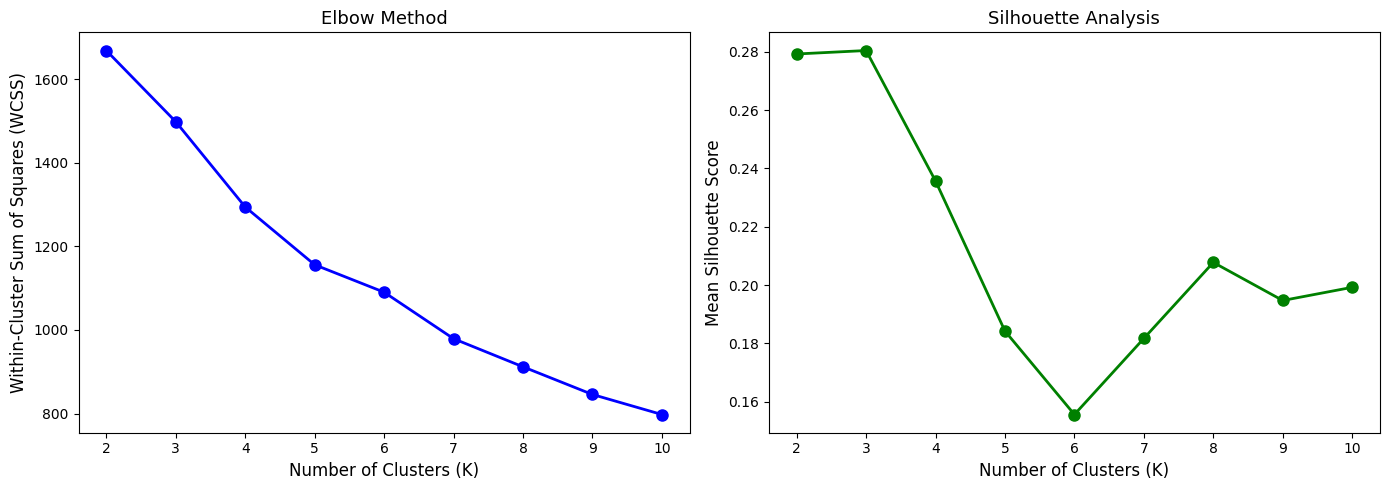

K  | WCSS       | Silhouette
---|------------|----------
2  |     1668.3 | 0.2793
3  |     1498.1 | 0.2805
4  |     1294.1 | 0.2357
5  |     1155.9 | 0.1842
6  |     1090.2 | 0.1556
7  |      979.0 | 0.1817
8  |      911.8 | 0.2078
9  |      845.6 | 0.1947
10  |      797.7 | 0.1992

Best K by silhouette score: 3


In [35]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 4: Elbow plot and silhouette analysis
# -----------------------------------------------------------

K_range = range(2, 11)
wcss_list = []
sil_list = []

for k in K_range:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init='auto',
        random_state=42
    )
    labels = km.fit_predict(X_scaled) # FILL IN: what data do we cluster?

    # Append WCSS (inertia)
    wcss_list.append(km.inertia_)     # FILL IN: attribute that stores WCSS

    # Append silhouette score
    sil_list.append(silhouette_score(X_scaled, labels))  # FILL IN: (data, labels)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, wcss_list, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=13)

# Silhouette plot
axes[1].plot(K_range, sil_list, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Mean Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontsize=13)

plt.tight_layout()
plt.show()

# Print scores
print('K  | WCSS       | Silhouette')
print('---|------------|----------')
for k, w, s in zip(K_range, wcss_list, sil_list):
    print(f'{k}  | {w:>10.1f} | {s:.4f}')

best_k = list(K_range)[np.argmax(sil_list)]
print(f'\nBest K by silhouette score: {best_k}')

=== Cross-Tabulation: K-Means Clusters vs World Bank Income Groups ===
wb_income  High  Low  Lower-Middle  Upper-Middle  All
cluster                                              
0             0   20            25             1   46
1            32    0             0             0   32
2             0    2             8             6   16
3            52    3            17            47  119
All          84   25            50            54  213



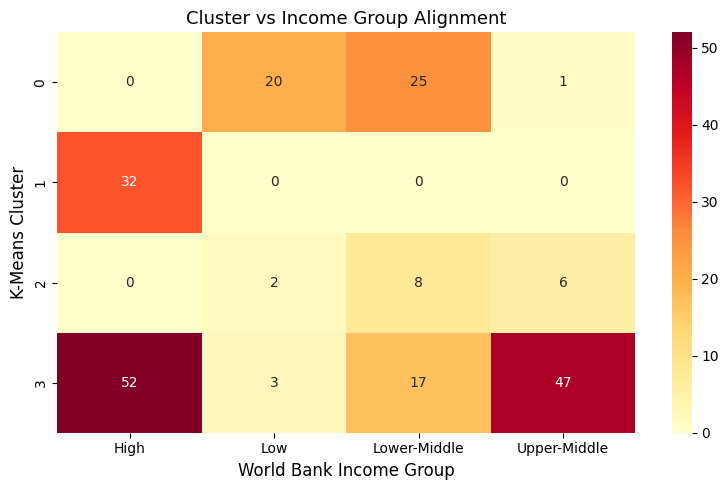

Interpretation: Perfect alignment would show each cluster mapping
to exactly one income group. Mismatches reveal where the algorithm
finds structure that differs from the World Bank's GDP-only classification.


In [36]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 5: Cross-tabulate clusters vs World Bank income groups
# -----------------------------------------------------------

# Fetch World Bank income group classification
income_groups = {}
for economy in wb.economy.list():
    # Ensure economy has a 'get' method (i.e., is dict-like)
    if not hasattr(economy, 'get'):
        print(f"Warning: Skipping item from wb.economy.list() that is not dict-like: {economy} (type: {type(economy)})")
        continue

    economy_id = economy.get('id')
    if economy_id is None:
        print(f"Warning: Skipping economy item without 'id' key: {economy}")
        continue

    # Get income level data, which can be a dict or a string directly
    income_level_data = economy.get('incomeLevel')

    if isinstance(income_level_data, dict):
        # If it's a dictionary, extract the 'id' key
        income_groups[economy_id] = income_level_data.get('id', 'Unknown')
    elif isinstance(income_level_data, str):
        # If it's already a string, use it directly
        income_groups[economy_id] = income_level_data
    else:
        # Fallback for any other unexpected type
        income_groups[economy_id] = 'Unknown'

# Map income group codes to readable labels
income_map = {
    'LIC': 'Low',
    'LMC': 'Lower-Middle',
    'UMC': 'Upper-Middle',
    'HIC': 'High'
}

df['wb_income'] = df.index.map(income_groups)
df['wb_income'] = df['wb_income'].map(income_map).fillna('Unknown')

# Drop unknowns for comparison
df_compare = df[df['wb_income'] != 'Unknown'].copy()

# Cross-tabulation
# Fill in: which two columns go into the crosstab?
ct = pd.crosstab(
    df_compare['cluster'],   # FILL IN: algorithmic cluster column
    df_compare['wb_income'],   # FILL IN: World Bank income group column
    margins=True
)
print('=== Cross-Tabulation: K-Means Clusters vs World Bank Income Groups ===')
print(ct)
print()

# Visualize as a heatmap
fig, ax = plt.subplots(figsize=(8, 5))
ct_no_margins = ct.iloc[:-1, :-1]  # Remove margins for heatmap
sns.heatmap(ct_no_margins, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_xlabel('World Bank Income Group', fontsize=12)
ax.set_ylabel('K-Means Cluster', fontsize=12)
ax.set_title('Cluster vs Income Group Alignment', fontsize=13)
plt.tight_layout()
plt.show()

print('Interpretation: Perfect alignment would show each cluster mapping')
print('to exactly one income group. Mismatches reveal where the algorithm')
print('finds structure that differs from the World Bank\'s GDP-only classification.')

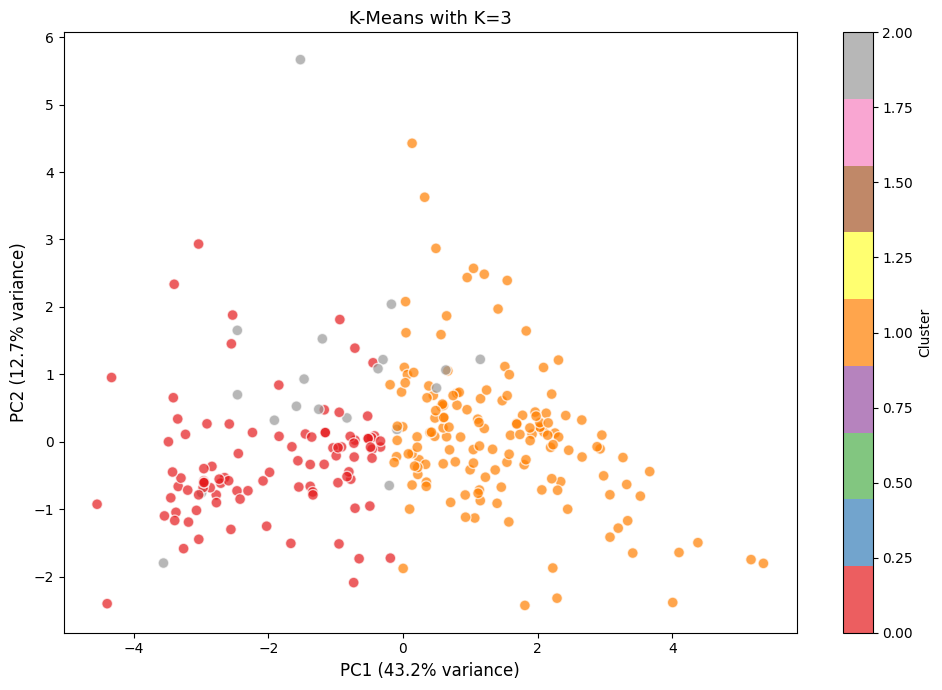

K=3 — Silhouette Score: 0.2805

Cluster 0: 96 countries | GDP/cap $8,836 | Life Exp 67.3 | Infant Mort 34.1
Cluster 1: 148 countries | GDP/cap $45,797 | Life Exp 78.4 | Infant Mort 8.5
Cluster 2: 19 countries | GDP/cap $11,497 | Life Exp 68.2 | Infant Mort 29.1


In [40]:
# -----------------------------------------------------------
# EXTENSION — Peer Programming: Cluster Debate
# Partner A fits K=3, Partner B fits K=5
# -----------------------------------------------------------

# Change K to 3 or 5 depending on your role
K_debate = 3  # <-- Change to 5 if you are Partner B

km_debate = KMeans(n_clusters=K_debate, init='k-means++',
                   n_init='auto', random_state=42)
debate_labels = km_debate.fit_predict(X_scaled)

# PCA scatter plot
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=debate_labels, cmap='Set1',
    alpha=0.7, edgecolors='white', s=60
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title(f'K-Means with K={K_debate}', fontsize=13)
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

# Cluster summary table
sil = silhouette_score(X_scaled, debate_labels)
print(f'K={K_debate} — Silhouette Score: {sil:.4f}')
print()
for k in range(K_debate):
    mask = debate_labels == k
    n_countries = mask.sum()
    avg_gdp = df.loc[mask, 'gdp_per_capita_ppp'].mean()
    avg_le = df.loc[mask, 'life_expectancy'].mean()
    avg_im = df.loc[mask, 'infant_mortality'].mean()
    print(f'Cluster {k}: {n_countries} countries | '
          f'GDP/cap ${avg_gdp:,.0f} | Life Exp {avg_le:.1f} | '
          f'Infant Mort {avg_im:.1f}')

I would use K=3 as the world bank because it produces a far more interpretable graph and more distinct clusters. The graph with K=5 has overlapping clusters and it is hard to differentiate them or come to a conclusion due to the fact that they join together on the graph. The K=3 graph gives us an easier visualizations, where the clusters are further apart and easier to interpret.

Shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']



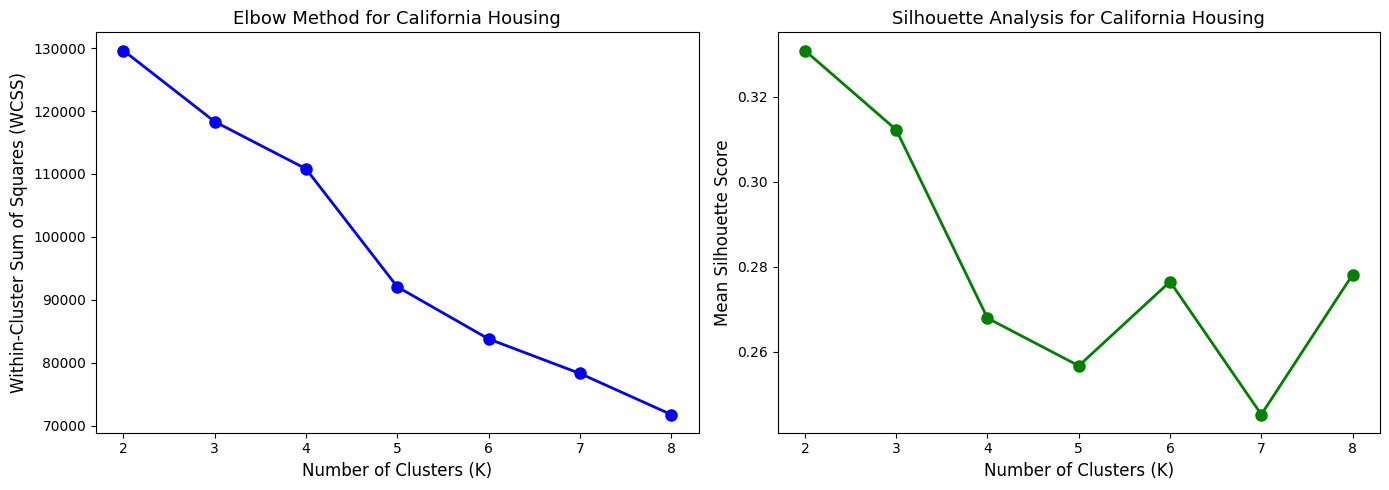

K  | WCSS       | Silhouette
2  |   129613.2 | 0.3308
3  |   118310.2 | 0.3122
4  |   110812.1 | 0.2679
5  |    92066.1 | 0.2567
6  |    83783.0 | 0.2765
7  |    78299.1 | 0.2453
8  |    71769.4 | 0.2782

Best K by silhouette score: 2
Variance explained by PC1: 25.3%
Variance explained by PC2: 23.5%
Total variance explained:  48.9%


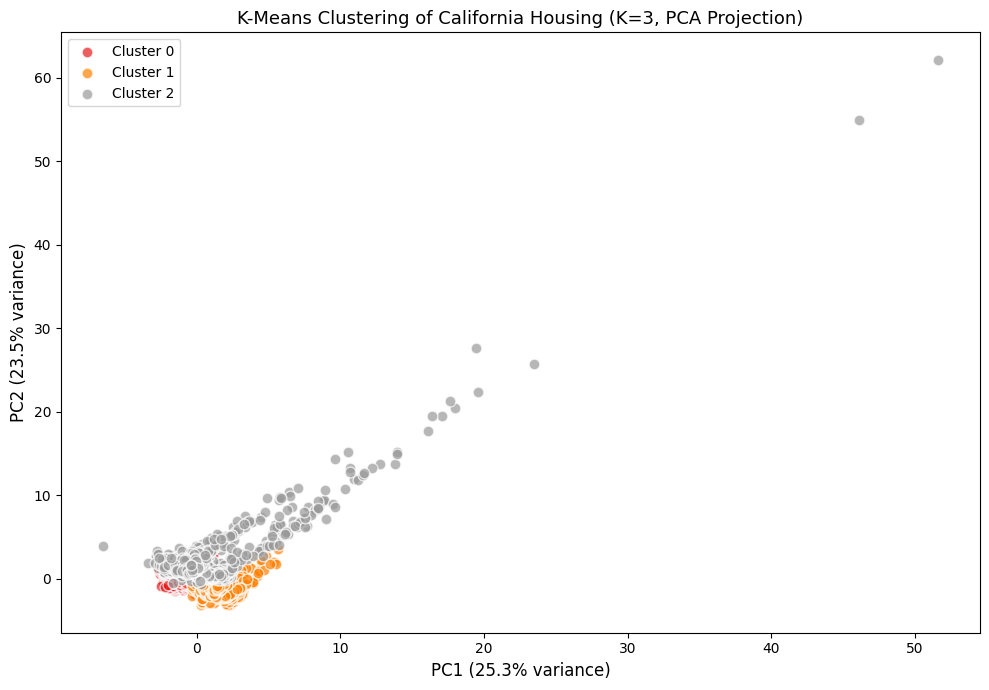

=== Cluster Summary (K=3) ===
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
cluster                                                                
0          3.27     31.19      4.76       1.06     1368.04      3.07   
1          3.64     29.54      5.40       1.08     1236.52      2.78   
2          6.43     17.94      7.68       1.26     2133.51      3.88   

         Latitude  Longitude  
cluster                       
0           33.97    -118.04  
1           37.98    -121.76  
2           34.48    -118.43  

Interpretation:
Cluster 0:
  Avg MedInc: 3.27
  Avg HouseAge: 31.19
  Avg AveRooms: 4.76
  Avg AveBedrms: 1.06
  Avg Population: 1368.04
  Avg AveOccup: 3.07
  Avg Latitude: 33.97
  Avg Longitude: -118.04

Cluster 1:
  Avg MedInc: 3.64
  Avg HouseAge: 29.54
  Avg AveRooms: 5.40
  Avg AveBedrms: 1.08
  Avg Population: 1236.52
  Avg AveOccup: 2.78
  Avg Latitude: 37.98
  Avg Longitude: -121.76

Cluster 2:
  Avg MedInc: 6.43
  Avg HouseAge: 17.94
  Avg

In [44]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Challenge: California Housing Clustering
# Apply the full pipeline: load → standardize → K-Means → PCA → interpret
# -----------------------------------------------------------

from sklearn.datasets import fetch_california_housing

# Step A: Load data
cal = fetch_california_housing(as_frame=True)
cal_df = cal.frame
print(f'Shape: {cal_df.shape}')
print(f'Features: {list(cal_df.columns)}')
print()

#step B: Select features for clustering
# Exclude the target variable (MedHouseVal) — we are doing UNSUPERVISED learning
cal_features = cal_df.drop(columns=['MedHouseVal'])

# Step C: Standardize
scaler_cal = StandardScaler()
cal_scaled = scaler_cal.fit_transform(cal_features)


# Step D: Find optimal K (elbow + silhouette for K=2..8)
K_range_cal = range(2, 9) # K from 2 to 8
wcss_list_cal = []
sil_list_cal = []

for k in K_range_cal:
    km_cal = KMeans(
        n_clusters=k,
        init='k-means++',            # Initialization method
        n_init='auto',
        random_state=42     # For reproducibility
    )
    labels_cal = km_cal.fit_predict(cal_scaled)

    wcss_list_cal.append(km_cal.inertia_)
    sil_list_cal.append(silhouette_score(cal_scaled, labels_cal))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range_cal, wcss_list_cal, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method for California Housing', fontsize=13)

axes[1].plot(K_range_cal, sil_list_cal, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Mean Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis for California Housing', fontsize=13)

plt.tight_layout()
plt.show()

print('K  | WCSS       | Silhouette')
for k, w, s in zip(K_range_cal, wcss_list_cal, sil_list_cal):
    print(f'{k}  | {w:>10.1f} | {s:.4f}')

best_k_cal = list(K_range_cal)[np.argmax(sil_list_cal)]
print(f'\nBest K by silhouette score: {best_k_cal}')


# Step E: Fit K-Means with your chosen K

chosen_k = 3 #
kmeans_cal = KMeans(
    n_clusters=chosen_k,
    init='k-means++',
    n_init='auto',
    random_state=42
)
cal_df['cluster'] = kmeans_cal.fit_predict(cal_scaled)


# Step F: PCA 2D visualization colored by cluster
pca_cal = PCA(n_components=2)
X_pca_cal = pca_cal.fit_transform(cal_scaled)

print(f'Variance explained by PC1: {pca_cal.explained_variance_ratio_[0]:.1%}')
print(f'Variance explained by PC2: {pca_cal.explained_variance_ratio_[1]:.1%}')
print(f'Total variance explained:  {sum(pca_cal.explained_variance_ratio_):.1%}')

fig, ax = plt.subplots(figsize=(10, 7))
colors_cal = plt.cm.get_cmap('Set1', chosen_k)

for k in range(chosen_k):
    mask = cal_df['cluster'] == k
    ax.scatter(
        X_pca_cal[mask, 0], X_pca_cal[mask, 1],
        c=[colors_cal(k)], label=f'Cluster {k}', # Pass color as a list
        alpha=0.7, edgecolors='white', s=60
    )

ax.set_xlabel(f'PC1 ({pca_cal.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_cal.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title(f'K-Means Clustering of California Housing (K={chosen_k}, PCA Projection)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


# Step G: Cluster summary table
# Print mean of each feature per cluster
# Label each cluster with an economically meaningful name
print(f'=== Cluster Summary (K={chosen_k}) ===')
cluster_summary = cal_df.groupby('cluster')[cal_features.columns].mean()
print(cluster_summary.round(2))

# Basic interpretation of clusters (example, will vary based on K and data)
print('\nInterpretation:')
for cluster_id in range(chosen_k):
    print(f'Cluster {cluster_id}:')
    for feature, value in cluster_summary.loc[cluster_id].items():
        print(f'  Avg {feature}: {value:.2f}')
    print()